# Notebook 07 — Transformer Backbone

**Purpose:** Define, pre-train, and save the Transformer backbone.

**Architecture — Sensor-as-Token Transformer:**
```
For each sensor stream:
  (batch, T=250, 3)
    → Temporal encoder (lightweight CNN): extracts local temporal features
    → Linear projection → (batch, d_model)    ← one token per stream

Sensor token sequence:
  n_streams tokens, each (batch, d_model)
    → Prepend learnable [CLS] token
    → Add learnable sensor position embeddings
    → Stack → (batch, n_streams+1, d_model)
    → Transformer encoder (self-attention across sensor tokens)
    → Extract [CLS] token output → (batch, d_model)
    → Linear projection → (batch, EMBEDDING_DIM=128)

Classification head (pre-training):
  Linear(128 → n_classes)
```

**Why sensor-as-token:**
- Self-attention explicitly learns which sensors are most informative
  for each activity — e.g. gyroscope matters more than magnetometer
  for fast movements
- No raw sensor concatenation — device boundaries are respected
- Attention weights are interpretable (which sensor attended to which)
- Naturally handles variable numbers of streams across datasets

**Why learnable sensor position embeddings instead of sinusoidal:**
- Sensor positions are not ordered sequences — they are physical devices
- Learnable embeddings let the model encode sensor identity,
  not just position order

**Interface is identical to CNN and LSTM backbones:**  
`backbone.get_embedding(stream_list)` → `(batch, 128)`

---
**Run notebook 00 first. Run at least notebook 01 (WISDM) before this.**

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

# ─── Which dataset to train on ────────────────────────────────────────────────
DATASET_NAME = 'wisdm'

print(f'\n✅ Setup complete')
print(f'   Backbone : Transformer (Sensor-as-Token)')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   Device   : {DEVICE}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Load Dataset

In [ ]:
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']

n_streams  = len(stream_names)
n_classes  = cfg['n_classes']
N, T, C    = streams[stream_names[0]].shape

# Force both sides to strings for bulletproof matching
sub_ids_str = subject_ids.astype(str)
train_split = [str(s) for s in split_info['train']]
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

# Build subject masks
train_mask = get_split_mask(sub_ids_str, train_split)
val_mask   = get_split_mask(sub_ids_str, val_split)
test_mask  = get_split_mask(sub_ids_str, test_split)

print(f'── Dataset summary ──')
print(f'   Dataset    : {DATASET_NAME}')
print(f'   N windows  : {N:,}')
print(f'   T timesteps: {T}')
print(f'   Streams    : {n_streams}  →  {stream_names}')
print(f'   Classes    : {n_classes}')
print(f'   Train      : {train_mask.sum():,} | Val: {val_mask.sum():,} | Test: {test_mask.sum():,}')

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset summary ──
   Dataset    : wisdm
   N windows  : 63,513
   T timesteps: 250
   Streams    : 4  →  ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']
   Classes    : 18
   Train      : 47,037 | Val: 7,596 | Test: 8,880


## Cell 3 — Transformer Backbone Architecture

Three components:
1. `StreamTemporalEncoder` — lightweight CNN that reduces `(batch, T, 3)`
   to a `d_model`-dimensional token, capturing local temporal patterns
2. `SensorTokenTransformer` — self-attention over sensor tokens plus `[CLS]`
3. `TransformerBackbone` — combines both, provides FSL interface

**Justification - Dropout Rates:** A lighter 0.1 dropout was used, as the Transformer already benefits from the heavy regularization of AdamW weight decay.

In [ ]:
class StreamTemporalEncoder(nn.Module):
    """
    Lightweight temporal encoder that converts a sensor stream
    (batch, T, 3) into a single d_model-dimensional token (batch, d_model).

    Uses a 2-block CNN followed by adaptive pooling.
    Lightweight by design — the heavy lifting is done by the Transformer.
    """

    def __init__(self, in_channels: int = 3, d_model: int = 64):
        super().__init__()

        self.encoder = nn.Sequential(
            # Block 1: capture local motion patterns
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),   # T → T/4

            # Block 2: capture higher-level patterns
            nn.Conv1d(32, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # collapse to single vector
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, T, 3)
        Returns:
            (batch, d_model) — one token per stream
        """
        x = x.permute(0, 2, 1)          # (batch, 3, T) for Conv1d
        x = self.encoder(x)              # (batch, d_model, 1)
        return x.squeeze(-1)             # (batch, d_model)


class TransformerBackbone(nn.Module):
    """
    Sensor-as-Token Transformer backbone.

    Each sensor stream becomes one token. A learnable [CLS] token
    is prepended. Self-attention learns inter-sensor relationships.
    The [CLS] output is the joint embedding.

    Interface is identical to CNNBackbone and LSTMBackbone.
    """

    def __init__(
        self,
        n_streams      : int,
        n_classes      : int,
        in_channels    : int   = 3,
        d_model        : int   = 64,
        nhead          : int   = 4,
        num_layers     : int   = 2,
        dim_feedforward: int   = 256,
        dropout        : float = 0.1,
        embedding_dim  : int   = EMBEDDING_DIM,
    ):
        """
        Args:
            n_streams       : number of sensor streams
            n_classes       : number of activity classes
            in_channels     : axes per stream (always 3)
            d_model         : token dimension for Transformer
            nhead           : attention heads — must divide d_model evenly
            num_layers      : Transformer encoder layers
            dim_feedforward : feedforward dim inside Transformer
            dropout         : dropout rate
            embedding_dim   : output joint embedding dimension (128)
        """
        super().__init__()

        assert d_model % nhead == 0, (
            f'd_model ({d_model}) must be divisible by nhead ({nhead})'
        )

        self.n_streams     = n_streams
        self.d_model       = d_model
        self.embedding_dim = embedding_dim

        # ── Per-stream temporal encoder ───────────────────────────────────────
        # One encoder per stream — each produces one d_model-dimensional token
        self.stream_encoders = nn.ModuleList([
            StreamTemporalEncoder(in_channels=in_channels, d_model=d_model)
            for _ in range(n_streams)
        ])

        # ── Learnable [CLS] token ─────────────────────────────────────────────
        # Initialized from N(0, 1), learned during training
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # ── Learnable sensor position embeddings ──────────────────────────────
        # n_streams + 1 positions (including CLS at position 0)
        # These encode sensor identity, not sequential position
        self.sensor_pos_embedding = nn.Parameter(
            torch.randn(1, n_streams + 1, d_model)
        )

        # ── Transformer encoder ───────────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,    # input: (batch, seq_len, d_model)
            norm_first      = True,    # Pre-LN: more stable training
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers = num_layers,
            norm       = nn.LayerNorm(d_model),
        )

        # ── Projection head ───────────────────────────────────────────────────
        # CLS token output → joint embedding
        self.projection = nn.Sequential(
            nn.Linear(d_model, embedding_dim),
            nn.ReLU(),
        )

        # ── Classification head (pre-training only) ───────────────────────────
        self.classifier = nn.Linear(embedding_dim, n_classes)

        # ── Dropout ───────────────────────────────────────────────────────────
        self.dropout = nn.Dropout(p=dropout)

        # ── Weight initialisation ─────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        """Initialize weights for stable training."""
        # CLS token and position embeddings — small normal
        nn.init.normal_(self.cls_token,           std=0.02)
        nn.init.normal_(self.sensor_pos_embedding, std=0.02)
        # Linear layers — truncated normal
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(
        self,
        stream_list      : List[torch.Tensor],
        return_embedding : bool = False
    ) -> torch.Tensor:
        """
        Args:
            stream_list      : list of n_streams tensors, each (batch, T, 3)
            return_embedding : True → (batch, 128) | False → (batch, n_classes)
        """
        assert len(stream_list) == self.n_streams, (
            f'Expected {self.n_streams} streams, got {len(stream_list)}'
        )

        batch_size = stream_list[0].shape[0]

        # ── Step 1: encode each stream → one token per stream ─────────────────
        stream_tokens = [
            encoder(stream)          # each: (batch, d_model)
            for encoder, stream in zip(self.stream_encoders, stream_list)
        ]
        # Stack to (batch, n_streams, d_model)
        tokens = torch.stack(stream_tokens, dim=1)

        # ── Step 2: prepend [CLS] token ───────────────────────────────────────
        # cls_token shape: (1, 1, d_model) → expand to (batch, 1, d_model)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # Concatenate: (batch, n_streams+1, d_model)
        tokens = torch.cat([cls_tokens, tokens], dim=1)

        # ── Step 3: add learnable sensor position embeddings ──────────────────
        tokens = tokens + self.sensor_pos_embedding   # broadcast over batch
        tokens = self.dropout(tokens)

        # ── Step 4: Transformer self-attention across sensor tokens ───────────
        # output: (batch, n_streams+1, d_model)
        encoded = self.transformer_encoder(tokens)

        # ── Step 5: extract [CLS] token ───────────────────────────────────────
        # CLS is at position 0 — it has attended to all sensor tokens
        cls_output = encoded[:, 0, :]    # (batch, d_model)

        # ── Step 6: project to embedding dim ─────────────────────────────────
        embedding = self.projection(cls_output)   # (batch, embedding_dim)

        if return_embedding:
            return embedding

        return self.classifier(embedding)

    def get_embedding(self, stream_list: List[torch.Tensor]) -> torch.Tensor:
        """Convenience method — always returns embedding. Used by FSL methods."""
        return self.forward(stream_list, return_embedding=True)

    def get_attention_weights(
        self,
        stream_list: List[torch.Tensor]
    ) -> torch.Tensor:
        """
        Extract attention weights from the first Transformer layer.
        Useful for visualising which sensors attend to which.

        Returns:
            attn_weights : (batch, nhead, n_streams+1, n_streams+1)
        """
        batch_size = stream_list[0].shape[0]

        stream_tokens = [
            encoder(s) for encoder, s in zip(self.stream_encoders, stream_list)
        ]
        tokens = torch.stack(stream_tokens, dim=1)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        tokens = tokens + self.sensor_pos_embedding

        # Get attention weights from first layer's multi-head attention
        first_layer = self.transformer_encoder.layers[0]
        with torch.no_grad():
            _, attn_weights = first_layer.self_attn(
                tokens, tokens, tokens,
                need_weights=True,
                average_attn_weights=False,
            )
        return attn_weights   # (batch, nhead, seq_len, seq_len)


# ─── Architecture test ────────────────────────────────────────────────────────
print('Testing Transformer backbone architecture...')
_batch  = 8
_model  = TransformerBackbone(
    n_streams  = n_streams,
    n_classes  = n_classes,
    d_model    = 64,
    nhead      = 4,
    num_layers = 2,
).to(DEVICE)

_dummy  = [torch.randn(_batch, T, C).to(DEVICE) for _ in range(n_streams)]
_emb    = _model(_dummy, return_embedding=True)
_logits = _model(_dummy, return_embedding=False)

print(f'   n_streams          : {n_streams}')
print(f'   Input/stream       : (batch={_batch}, T={T}, C={C})')
print(f'   Token sequence     : (batch={_batch}, seq={n_streams+1}, d_model=64)')
print(f'                         └─ [CLS] + {n_streams} sensor tokens')
print(f'   Embedding          : {_emb.shape}    (expected ({_batch}, {EMBEDDING_DIM}))')
print(f'   Logits             : {_logits.shape}  (expected ({_batch}, {n_classes}))')

n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'   Trainable params   : {n_params:,}')

# Test attention weight extraction
_attn = _model.get_attention_weights(_dummy)
print(f'   Attention weights  : {_attn.shape}')
print(f'                         └─ (batch, nhead, seq_len, seq_len) = '
      f'({_batch}, 4, {n_streams+1}, {n_streams+1})')

assert _emb.shape    == (_batch, EMBEDDING_DIM)
assert _logits.shape == (_batch, n_classes)
del _model, _dummy, _emb, _logits, _attn
print('\n✅ Architecture test passed')

Testing Transformer backbone architecture...
   n_streams          : 4
   Input/stream       : (batch=8, T=250, C=3)
   Token sequence     : (batch=8, seq=5, d_model=64)
                         └─ [CLS] + 4 sensor tokens
   Embedding          : torch.Size([8, 128])    (expected (8, 128))
   Logits             : torch.Size([8, 18])  (expected (8, 18))
   Trainable params   : 155,922
   Attention weights  : torch.Size([8, 4, 5, 5])
                         └─ (batch, nhead, seq_len, seq_len) = (8, 4, 5, 5)

✅ Architecture test passed


## Cell 4 — DataLoaders

In [ ]:
# ─── Augmentation utilities ───────────────────────────────────────────────────
def augment_stream(x: torch.Tensor) -> torch.Tensor:
    """Apply sensor-agnostic augmentation to a single stream."""
    if torch.rand(1) < 0.5:
        noise = 0.01 * torch.randn_like(x)
        x = x + noise
    if torch.rand(1) < 0.5:
        scale = torch.randn(1).item() * 0.1 + 1.0
        x = x * scale
    if torch.rand(1) < 0.3:
        T = x.shape[0]
        mask_len = int(0.1 * T)
        start = torch.randint(0, T - mask_len, (1,)).item()
        x[start:start+mask_len] = 0
    if torch.rand(1) < 0.5:
        theta = torch.randn(1).item() * 0.2
        cos, sin = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
        R = torch.tensor([
            [cos, -sin, 0],
            [sin,  cos, 0],
            [0,    0,   1]
        ], dtype=torch.float32)
        x = x @ R
    return x

# ─── Dataset ──────────────────────────────────────────────────────────────────
class MultiStreamDataset(torch.utils.data.Dataset):
    def __init__(
        self, streams: Dict[str, np.ndarray], y: np.ndarray,
        stream_names: List[str], mask: np.ndarray, augment: bool = False,
    ):
        self.stream_arrays = [streams[name][mask].astype(np.float32) for name in stream_names]
        self.labels       = y[mask].astype(np.int64)
        self.n_samples    = mask.sum()
        self.stream_names = stream_names
        self.augment      = augment

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int):
        stream_list = []
        for arr in self.stream_arrays:
            x = torch.tensor(arr[idx], dtype=torch.float32)
            if self.augment:
                x = augment_stream(x)
            stream_list.append(x)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return stream_list, label

def multistream_collate(batch):
    stream_lists, labels = zip(*batch)
    n_streams = len(stream_lists[0])
    batched_streams = [
        torch.stack([s[i] for s in stream_lists], dim=0)
        for i in range(n_streams)
    ]
    batched_labels = torch.stack(labels, dim=0)
    return batched_streams, batched_labels

# ─── Build datasets and loaders ───────────────────────────────────────────────
train_dataset = MultiStreamDataset(streams, y, stream_names, train_mask, augment=True)
val_dataset   = MultiStreamDataset(streams, y, stream_names, val_mask, augment=False)
test_dataset  = MultiStreamDataset(streams, y, stream_names, test_mask, augment=False)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=multistream_collate, num_workers=0,
    pin_memory=True if DEVICE.type == 'cuda' else False,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=multistream_collate, num_workers=0,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=multistream_collate, num_workers=0,
)

print('✅ DataLoaders ready (with augmentation)')
print(f'   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ DataLoaders ready (with augmentation)
   Train: 1470 batches | Val: 238 | Test: 278


## Cell 5 — Training Utilities

Same pattern as notebooks 05 and 06.

In [ ]:
def train_one_epoch(
    model     : nn.Module,
    loader    : torch.utils.data.DataLoader,
    optimizer : torch.optim.Optimizer,
    criterion : nn.Module,
) -> Tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0

    for stream_list, labels in loader:
        stream_list = [s.to(DEVICE) for s in stream_list]
        labels      = labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(stream_list, return_embedding=False)
        loss   = criterion(logits, labels)
        loss.backward()
        # Gradient clipping — good practice for Transformers too
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model     : nn.Module,
    loader    : torch.utils.data.DataLoader,
    criterion : nn.Module,
) -> Tuple[float, float, float]:
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for stream_list, labels in loader:
        stream_list = [s.to(DEVICE) for s in stream_list]
        labels      = labels.to(DEVICE)
        logits      = model(stream_list, return_embedding=False)
        loss        = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.append(logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (
        total_loss / len(all_labels),
        compute_accuracy(all_labels, all_preds),
        compute_macro_f1(all_labels, all_preds),
    )


print('✅ Training utilities defined')

✅ Training utilities defined


## Cell 6 — Initialise Model, Optimizer, Scheduler

Transformer uses a **warm-up + cosine decay** schedule.  
This is standard for Transformer training — the warm-up prevents  
large gradient updates in the early epochs when attention weights  
are still random and unstable.

**Justification - Optimization Dynamics:** Unlike CNNs/LSTMs, Transformers lack early inductive bias. Therefore, a custom `LambdaLR` scheduler was implemented with a 5-epoch linear warmup. This prevents exploding gradients during early epochs before transitioning to a cosine decay. Aggressive weight decay (1e-2) was applied via the `AdamW` optimizer due to the Transformer's high parameter count and propensity to memorize training users.

In [ ]:
seed_everything(MASTER_SEED)

model = TransformerBackbone(
    n_streams       = n_streams,
    n_classes       = n_classes,
    in_channels     = C,
    d_model         = 64,
    nhead           = 4,      # 64 / 4 = 16 dims per head
    num_layers      = 2,
    dim_feedforward = 256,
    dropout         = 0.1,
    embedding_dim   = EMBEDDING_DIM,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

# AdamW — better weight decay handling than Adam for Transformers
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-2,      # slightly higher wd than CNN/LSTM
    betas        = (0.9, 0.999),
)

# Warm-up + cosine decay scheduler
# Warm-up: linearly increase LR from 0 to LEARNING_RATE over WARMUP_EPOCHS
# Then cosine decay to eta_min
WARMUP_EPOCHS = 5

def lr_lambda(epoch):
    """Linear warm-up then cosine decay."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    # Cosine decay from 1.0 to eta_min/LR after warm-up
    progress = (epoch - WARMUP_EPOCHS) / max(1, BACKBONE_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Transformer model initialised')
print(f'   Trainable params : {n_params:,}')
print(f'   d_model          : 64  (nhead=4, 16 dims/head)')
print(f'   Layers           : 2')
print(f'   Token sequence   : [CLS] + {n_streams} sensor tokens = {n_streams+1} total')
print(f'   Optimizer        : AdamW (lr={LEARNING_RATE}, wd=1e-2)')
print(f'   Schedule         : {WARMUP_EPOCHS}-epoch warm-up + cosine decay')
print(f'   Gradient clip    : max_norm=1.0')

✅ Transformer model initialised
   Trainable params : 155,922
   d_model          : 64  (nhead=4, 16 dims/head)
   Layers           : 2
   Token sequence   : [CLS] + 4 sensor tokens = 5 total
   Optimizer        : AdamW (lr=0.0003, wd=1e-2)
   Schedule         : 5-epoch warm-up + cosine decay
   Gradient clip    : max_norm=1.0


## Cell 7 — Training Loop

In [ ]:
ckpt_dir  = os.path.join(CHECKPOINT_BASE, DATASET_NAME, 'transformer')
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, 'best_backbone.pt')

PATIENCE       = 10
best_val_acc   = 0.0
patience_count = 0

history = {
    'train_loss':[], 'train_acc':[],
    'val_loss':  [], 'val_acc':  [], 'val_f1':[],
    'lr':        [],
}

print(f'Training Transformer backbone on {DATASET_NAME}...')
print(f'Checkpoint : {ckpt_path}')
print(f'Note: expect slow progress in first {WARMUP_EPOCHS} epochs (warm-up phase)')
print(f'{"─"*70}')
print(f'{"Epoch":>5} {"TrainLoss":>10} {"TrainAcc":>10} {"ValLoss":>10} {"ValAcc":>8} {"ValF1":>8} {"LR":>12}')
print(f'{"─"*70}')

for epoch in range(1, BACKBONE_EPOCHS + 1):
    train_loss, train_acc         = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc,  val_f1  = evaluate(model, val_loader, criterion)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc   = val_acc
        patience_count = 0
        save_checkpoint(
            model, ckpt_path,
            extra={
                'epoch'        : epoch,
                'val_acc'      : val_acc,
                'val_f1'       : val_f1,
                'dataset'      : DATASET_NAME,
                'backbone'     : 'transformer',
                'n_streams'    : n_streams,
                'n_classes'    : n_classes,
                'stream_names' : stream_names,
                'd_model'      : 64,
                'nhead'        : 4,
                'num_layers'   : 2,
            }
        )
    else:
        patience_count += 1

    warmup_marker = ' [WU]' if epoch <= WARMUP_EPOCHS else ''
    marker        = ' ✅' if improved else ''
    print(
        f'{epoch:>5} '
        f'{train_loss:>10.4f} '
        f'{train_acc*100:>9.2f}% '
        f'{val_loss:>10.4f} '
        f'{val_acc*100:>7.2f}% '
        f'{val_f1:>8.4f} '
        f'{current_lr:>12.6f}'
        f'{warmup_marker}{marker}'
    )

    if patience_count >= PATIENCE:
        print(f'\n   Early stopping at epoch {epoch}')
        break

print(f'\n{"─"*70}')
print(f'✅ Training complete — best val acc: {best_val_acc*100:.2f}%')

Training Transformer backbone on wisdm...
Checkpoint : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/best_backbone.pt
Note: expect slow progress in first 5 epochs (warm-up phase)
──────────────────────────────────────────────────────────────────────
Epoch  TrainLoss   TrainAcc    ValLoss   ValAcc    ValF1           LR
──────────────────────────────────────────────────────────────────────
    1     2.1189     33.28%     1.5507   48.85%   0.4248     0.000060 [WU] ✅
    2     1.3401     52.39%     1.1614   59.24%   0.5501     0.000120 [WU] ✅
    3     1.0801     61.52%     1.0713   63.16%   0.6161     0.000180 [WU] ✅
    4     0.9370     66.49%     1.1333   64.72%   0.6424     0.000240 [WU] ✅
    5     0.8527     69.62%     1.0037   64.68%   0.6388     0.000300 [WU]
    6     0.7749     72.85%     1.0963   64.64%   0.6369     0.000300
    7     0.7153     75.07%     0.9413   71.38%   0.7076     0.000300 ✅
    8     0.6664     76.80%     1.0423   69.79%   0.6928     0.000299

## Cell 8 — Training Curves

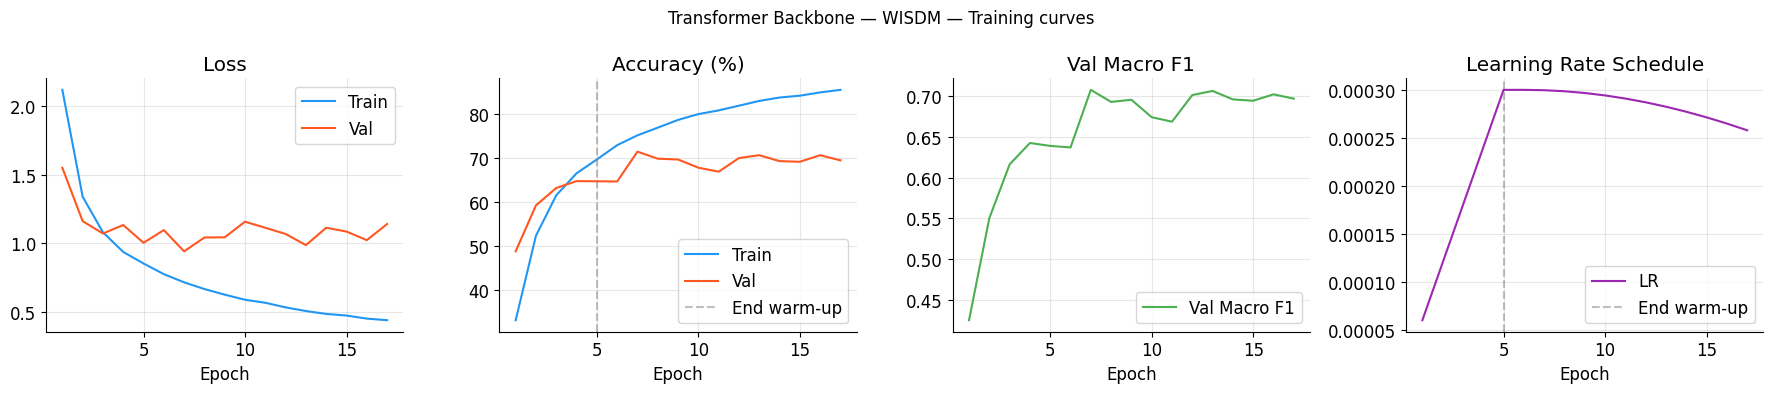

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/training_curves.png


In [ ]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(ep, history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#FF5722')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#2196F3')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#FF5722')
# Mark end of warm-up
axes[1].axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='End warm-up')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(ep, history['val_f1'], color='#4CAF50', label='Val Macro F1')
axes[2].set_title('Val Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

# LR schedule
axes[3].plot(ep, history['lr'], color='#9C27B0', label='LR')
axes[3].axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='End warm-up')
axes[3].set_title('Learning Rate Schedule')
axes[3].set_xlabel('Epoch')
axes[3].legend()

fig.suptitle(f'Transformer Backbone — {DATASET_NAME.upper()} — Training curves', fontsize=12)
plt.tight_layout()
plot_path = os.path.join(ckpt_dir, 'training_curves.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Cell 9 — Test Set Evaluation

In [ ]:
best_model = TransformerBackbone(
    n_streams       = n_streams,
    n_classes       = n_classes,
    in_channels     = C,
    d_model         = 64,
    nhead           = 4,
    num_layers      = 2,
    dim_feedforward = 256,
    dropout         = 0.1,
    embedding_dim   = EMBEDDING_DIM,
).to(DEVICE)

meta = load_checkpoint(best_model, ckpt_path)
print(f'Loaded checkpoint from epoch {meta.get("epoch", "?")}')

test_loss, test_acc, test_f1 = evaluate(best_model, test_loader, criterion)

print(f'\n── Test set results ──')
print(f'   Test accuracy  : {test_acc*100:.2f}%')
print(f'   Test macro F1  : {test_f1:.4f}')
print(f'   Test loss      : {test_loss:.4f}')

result = {
    'dataset'   : DATASET_NAME,
    'backbone'  : 'transformer',
    'method'    : 'pretrain_classifier',
    'k_shot'    : 0,
    'seed'      : MASTER_SEED,
    'acc_before': test_acc,
    'acc_after' : test_acc,
    'gain'      : 0.0,
    'macro_f1'  : test_f1,
    'best_epoch': meta.get('epoch', -1),
}
config_key = make_config_key(DATASET_NAME, 'transformer', 'pretrain', 0, MASTER_SEED)
mark_completed(config_key, result)
print(f'\n✅ Result saved to registry')

Loaded checkpoint from epoch 7

── Test set results ──
   Test accuracy  : 65.54%
   Test macro F1  : 0.6405
   Test loss      : 1.2087

✅ Result saved to registry


## Cell 10 — Full Backbone Comparison

Now that all three backbones have been trained, compare them side by side.  
This is the backbone comparison result for the thesis.

── Backbone comparison on WISDM (generalization, no adaptation) ──
Backbone          Test Acc   Macro F1   Best Epoch     Status
────────────────────────────────────────────────────────────
cnn                 69.11%     0.6766           19     ✅ done
lstm                64.92%     0.6402           42     ✅ done
transformer         65.54%     0.6405            7     ✅ done


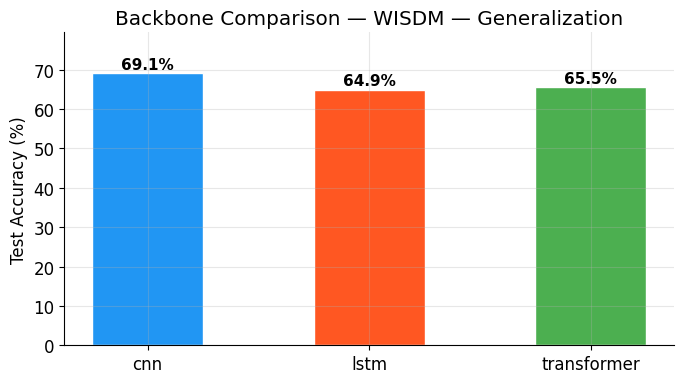


Saved comparison plot: /content/drive/MyDrive/fsl_har_results/backbone_comparison_wisdm.png


In [ ]:
registry = load_registry()

print(f'── Backbone comparison on {DATASET_NAME.upper()} (generalization, no adaptation) ──')
print(f'{"Backbone":<15} {"Test Acc":>10} {"Macro F1":>10} {"Best Epoch":>12} {"Status":>10}')
print('─' * 60)

results_for_plot = {}
for backbone_name in ['cnn', 'lstm', 'transformer']:
    key = make_config_key(DATASET_NAME, backbone_name, 'pretrain', 0, MASTER_SEED)
    if key in registry:
        r = registry[key]
        acc = r.get('acc_after', 0)
        f1  = r.get('macro_f1', 0)
        ep  = r.get('best_epoch', '?')
        results_for_plot[backbone_name] = acc
        print(f'{backbone_name:<15} {acc*100:>9.2f}% {f1:>10.4f} {str(ep):>12} {"✅ done":>10}')
    else:
        print(f'{backbone_name:<15} {"─":>10} {"─":>10} {"─":>12} {"not run":>10}')

# Plot comparison if all three are done
if len(results_for_plot) == 3:
    fig, ax = plt.subplots(figsize=(7, 4))
    names  = list(results_for_plot.keys())
    accs   = [results_for_plot[n] * 100 for n in names]
    colors = ['#2196F3', '#FF5722', '#4CAF50']
    bars   = ax.bar(names, accs, color=colors, edgecolor='white', width=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'Backbone Comparison — {DATASET_NAME.upper()} — Generalization')
    ax.set_ylim(0, max(accs) * 1.15)
    plt.tight_layout()
    cmp_path = os.path.join(RESULTS_BASE, f'backbone_comparison_{DATASET_NAME}.png')
    plt.savefig(cmp_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nSaved comparison plot: {cmp_path}')
else:
    print('\n(Run notebooks 05 and 06 first to see full comparison)')

## Cell 11 — Attention Weight Visualisation

Unique to the Transformer — shows which sensors attend to which.  
This is interpretable output that can go directly into the thesis.

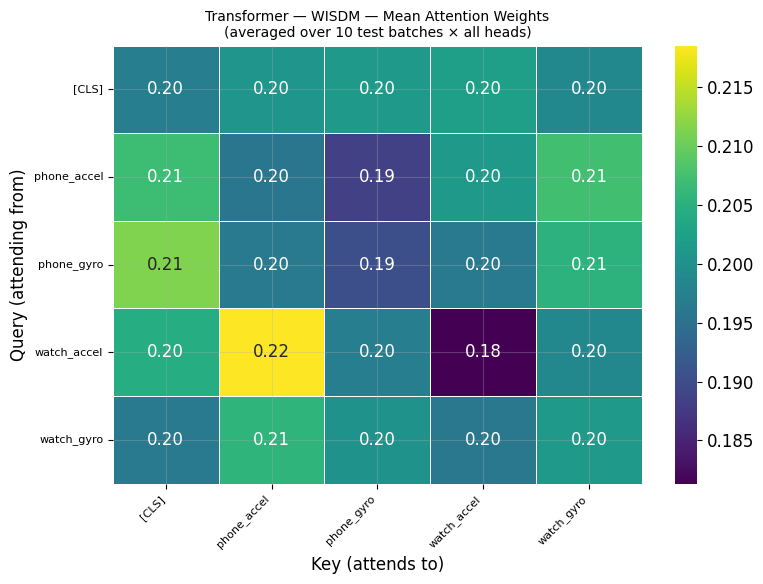

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/attention_weights.png

Interpretation guide:
  Row = which token is querying
  Col = which token is being attended to
  [CLS] row shows which sensors the model relies on most for classification
  High diagonal = each sensor mostly self-attends (early training)
  Off-diagonal  = sensors learning from each other (good sign)


In [ ]:
best_model.eval()

# Collect attention weights over test set — average across samples
all_attn = []
n_batches_to_sample = min(10, len(test_loader))   # use first 10 batches

with torch.no_grad():
    for i, (stream_list, _) in enumerate(test_loader):
        if i >= n_batches_to_sample:
            break
        stream_list = [s.to(DEVICE) for s in stream_list]
        attn = best_model.get_attention_weights(stream_list)   # (batch, nhead, seq, seq)
        all_attn.append(attn.cpu().numpy())

# Average over batches, heads → (seq_len, seq_len)
mean_attn = np.concatenate(all_attn, axis=0).mean(axis=(0, 1))
seq_labels = ['[CLS]'] + stream_names

fig, ax = plt.subplots(figsize=(max(8, n_streams+2), max(6, n_streams+1)))
sns.heatmap(
    mean_attn,
    xticklabels = seq_labels,
    yticklabels = seq_labels,
    cmap        = 'viridis',
    annot       = True,
    fmt         = '.2f',
    ax          = ax,
    linewidths  = 0.5,
)
ax.set_title(
    f'Transformer — {DATASET_NAME.upper()} — Mean Attention Weights\n'
    f'(averaged over {n_batches_to_sample} test batches × all heads)',
    fontsize=10
)
ax.set_xlabel('Key (attends to)')
ax.set_ylabel('Query (attending from)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

attn_path = os.path.join(ckpt_dir, 'attention_weights.png')
plt.savefig(attn_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {attn_path}')
print(f'\nInterpretation guide:')
print(f'  Row = which token is querying')
print(f'  Col = which token is being attended to')
print(f'  [CLS] row shows which sensors the model relies on most for classification')
print(f'  High diagonal = each sensor mostly self-attends (early training)')
print(f'  Off-diagonal  = sensors learning from each other (good sign)')

## Cell 12 — Verify FSL Interface

In [ ]:
print('Verifying Transformer backbone FSL interface...\n')

fsl_backbone = TransformerBackbone(
    n_streams       = n_streams,
    n_classes       = n_classes,
    in_channels     = C,
    d_model         = 64,
    nhead           = 4,
    num_layers      = 2,
    dim_feedforward = 256,
    dropout         = 0.1,
    embedding_dim   = EMBEDDING_DIM,
).to(DEVICE)

load_checkpoint(fsl_backbone, ckpt_path)
fsl_backbone.eval()

n_way, k_shot = cfg['n_way'], 5
support_batch = n_way * k_shot
dummy_support = [torch.randn(support_batch, T, C).to(DEVICE) for _ in range(n_streams)]

with torch.no_grad():
    emb = fsl_backbone.get_embedding(dummy_support)

assert emb.shape == (support_batch, EMBEDDING_DIM)
norms = emb.norm(dim=-1)

print(f'   Support batch      : {support_batch} ({n_way}-way × {k_shot}-shot)')
print(f'   Embedding shape    : {emb.shape}  ✅')
print(f'   Embedding norms    : mean={norms.mean():.3f}, std={norms.std():.3f}')

del fsl_backbone, dummy_support, emb
print(f'\n✅ Transformer backbone interface verified')
print(f'   FSL methods use the same get_embedding() call as CNN and LSTM')

Verifying Transformer backbone FSL interface...

   Support batch      : 25 (5-way × 5-shot)
   Embedding shape    : torch.Size([25, 128])  ✅
   Embedding norms    : mean=21.176, std=0.226

✅ Transformer backbone interface verified
   FSL methods use the same get_embedding() call as CNN and LSTM


## Cell 13 — Final Summary

In [ ]:
print('=' * 65)
print('  TRANSFORMER BACKBONE TRAINING COMPLETE')
print('=' * 65)
print(f'  Dataset          : {DATASET_NAME}')
print(f'  Architecture     : Sensor-as-Token Transformer')
print(f'                     d_model=64, nhead=4, layers=2')
print(f'  Token sequence   : [CLS] + {n_streams} sensor tokens = {n_streams+1} total')
print(f'  Streams          : {n_streams}')
print(f'  Classes          : {n_classes}')
print(f'  Embedding dim    : {EMBEDDING_DIM}')
print(f'  Epochs trained   : {epochs_ran}')
print(f'  Best val acc     : {best_val_acc*100:.2f}%')
print(f'  Test acc         : {test_acc*100:.2f}%  ← generalization baseline')
print(f'  Test macro F1    : {test_f1:.4f}')
print(f'  Checkpoint       : {ckpt_path}')
print('=' * 65)
print()
print('  Phase 3 backbone comparison is now complete.')
print('  All 3 backbones (CNN, LSTM, Transformer) trained on WISDM.')
print()
print('  Next steps:')
print('  Phase 2/3: → Notebook 08 (ProtoNet) — first FSL method')
print('             → Run with CNN backbone first (Phase 1 complete)')
print('             → Then repeat with LSTM and Transformer (Phase 3)')
print('=' * 65)

  TRANSFORMER BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Architecture     : Sensor-as-Token Transformer
                     d_model=64, nhead=4, layers=2
  Token sequence   : [CLS] + 4 sensor tokens = 5 total
  Streams          : 4
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 17
  Best val acc     : 71.38%
  Test acc         : 65.54%  ← generalization baseline
  Test macro F1    : 0.6405
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/best_backbone.pt

  Phase 3 backbone comparison is now complete.
  All 3 backbones (CNN, LSTM, Transformer) trained on WISDM.

  Next steps:
  Phase 2/3: → Notebook 08 (ProtoNet) — first FSL method
             → Run with CNN backbone first (Phase 1 complete)
             → Then repeat with LSTM and Transformer (Phase 3)
